# 24 &middot; Subspace Mixed FEM (MFEM)

We simulate an elastic 2D beam dropping under gravity, pinned at its left edge,
**two ways**:

* **Full-space FEM** &mdash; the classic recipe. One Newton solve per timestep on
  the elastic + inertial + pin energy, written as a function of the deformed
  positions.
* **Subspace Mixed FEM (MFEM)** &mdash; the method of
  [Trusty et&nbsp;al., *Subspace Mixed FEM*](https://www.dgp.toronto.edu/projects/subspace-mfem/).
  We solve in a small **skinning-eigenmode subspace** and introduce an
  **auxiliary stretch variable** so the elastic energy stays element-local and
  cheap, even though the subspace basis is dense.

Everything here is composed from **flat simkit functions** &mdash; no simulator
classes. The MFEM constrained system is solved with `simkit.solvers.sqp_mfem`.

## Why a subspace, and why "mixed"?

A reduced model writes every vertex position as

$$ \mathbf{x} = B\,\mathbf{u} + \mathbf{q}, $$

where $B$ is a tall **dense** basis (here, skinning eigenmodes) and $\mathbf{u}$
is a handful of reduced weights. Stepping then solves for $\mathbf{u}$ only, which
is great &mdash; until you evaluate the elastic energy. The elastic Hessian in the
subspace is $B^\top H B$: dense, and expensive to assemble because $H$ couples
the deformation gradient $F = \nabla(B\mathbf{u})$ across *all* elements.

**Mixed FEM** breaks that coupling. Introduce a per-element auxiliary
**stretch** variable $\mathbf{a}$ (the symmetric part of $F$, one small vector
per cubature element) and demand that it agree with the actual deformation:

$$ S\big(F(\mathbf{u})\big) = \mathbf{a}. $$

Now the elastic energy is a function of $\mathbf{a}$ **alone** &mdash; fully
*element-local*, so its Hessian $H_z$ is block-diagonal and trivial to build.
The only thing tying $\mathbf{a}$ back to the dense subspace is the constraint,
whose Jacobian $G_u$ is cheap. We minimize the Lagrangian

$$ \min_{\mathbf{u},\,\mathbf{a}}\; E_\text{inertia}(\mathbf{u}) + E_\text{elastic}(\mathbf{a}) + E_\text{pin}(\mathbf{u}) \quad\text{s.t.}\quad S(F(\mathbf{u})) = \mathbf{a}. $$


In [1]:
# --- make the *local* simkit (this repo) importable, ahead of any installed copy ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
%matplotlib inline
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

import simkit as sk
from simkit.solvers import sqp_mfem, newton_solver
from simkit.energies import (
    elastic_energy_S, elastic_gradient_S, elastic_hessian_S,        # element-local (stretch) energy
    elastic_energy_z, elastic_gradient_z, elastic_hessian_z, ElasticEnergyZPrecomp,  # FEM (subspace) energy
    quadratic_energy, quadratic_gradient, quadratic_hessian,        # pin + gravity
    kinetic_energy_be, kinetic_gradient_be, kinetic_hessian_be,     # backward-Euler inertia
)

# sparse @ on some scipy/numpy combos emits spurious 'divide by zero in matmul'
# warnings; the arithmetic is exact. Silence them for a clean notebook.
np.seterr(all="ignore")

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

## The mesh, subspace, and cubature

A long thin beam. We build:

* `B` &mdash; a **skinning-eigenmode** subspace (`sk.skinning_eigenmodes`).
  `x = B @ u + q`, with `q` the rest geometry, so `u = 0` is the rest pose.
* `cI, cW` &mdash; **spectral cubature** points and weights
  (`sk.spectral_cubature`): a sparse subset of elements (with weights) at which
  we evaluate the elastic energy, instead of all of them.


In [46]:
def triangulated_grid(nx, ny, width=2.0, height=1.0):
    xs = np.linspace(-width/2, width/2, nx); ys = np.linspace(-height/2, height/2, ny)
    XX, YY = np.meshgrid(xs, ys, indexing="xy")
    X = np.stack([XX.ravel(), YY.ravel()], axis=1)
    i, j = np.meshgrid(np.arange(nx-1), np.arange(ny-1), indexing="xy")
    v00=(j*nx+i).ravel(); v01=(j*nx+i+1).ravel(); v10=((j+1)*nx+i).ravel(); v11=((j+1)*nx+i+1).ravel()
    T = np.stack([np.stack([v00,v01,v11],1), np.stack([v00,v11,v10],1)],1).reshape(-1,3)
    return X, T

X, T = triangulated_grid(nx=40, ny=8, width=3.0, height=0.5)
n, dim = X.shape
q = X.reshape(-1, 1)                       # rest geometry offset:  x = B u + q

ym, pr, rho, h = 1e5, 0.45, 1e3, 1e1       # Young's modulus, Poisson, density, timestep
material = "macklin-mueller-neo-hookean"

# skinning-eigenmode subspace + spectral cubature
m, k = 10, 400
mu_tet = np.full((T.shape[0], 1), float(ym))
W, E, B = sk.skinning_eigenmodes(X, T, m, mu=mu_tet)
cI, cW, _ = sk.spectral_cubature(X, T, W, k, return_labels=True)
print(f"{n} vertices, {T.shape[0]} triangles, {n*dim} full DOFs")
print(f"subspace dim = {B.shape[1]},  cubature points = {cI.shape[0]}")

320 vertices, 546 triangles, 640 full DOFs
subspace dim = 60,  cubature points = 400


## Shared precomputation

Both methods share the reduced mass matrix `B^T M B` (backward-Euler inertia)
and the deformation-gradient operator restricted to the cubature elements,
`GJB` (so `F = GJB @ u + GJq`). The MFEM method additionally needs the
**symmetric-stretch map** `Ci` (extracts the symmetric stretch $S(F)$) and a
constraint metric `w` weighting each stretch component by its cubature volume.


In [47]:
# --- material (Lame) on cubature elements ---
mu_lame, lam_lame = sk.ympr_to_lame(ym, pr)
mu  = np.full((T.shape[0], 1), mu_lame)[cI]
lam = np.full((T.shape[0], 1), lam_lame)[cI]
vol = cW.reshape(-1, 1)

# --- inertia: reduced mass matrix ---
Mn = sk.massmatrix(X, T, rho=rho)
Mv = sp.sparse.kron(Mn, sp.sparse.identity(dim))
kin_pre = B.T @ Mv @ B

# --- deformation gradient at cubature elements:  F = GJB u + GJq ---
G  = sk.selection_matrix(cI, T.shape[0])
Ge = sp.sparse.kron(G, sp.sparse.identity(dim*dim))
J  = sk.deformation_jacobian(X, T)
GJB = Ge @ J @ B
GJq = Ge @ J @ q

# --- MFEM-only: symmetric stretch map + constraint metric ---
C, Ci = sk.symmetric_stretch_map(cI.shape[0], dim)
w  = np.kron(vol, np.array([[1., 1., 2.]]).T)   # dim==2: (s_xx, s_yy, s_xy) weights
Wd = sp.sparse.diags(w.flatten())
Wi = sp.sparse.diags(1.0 / w.flatten())   # inverse constraint metric
nz = B.shape[1]                 # number of subspace (position) DOFs
na = Ci.shape[0]                # number of stretch auxiliary DOFs

# --- external forcing: gravity (constant) + a stiff pin on the left edge ---
bg  = -sk.gravity_force(X, T, a=-9.81, rho=rho).reshape(-1, 1)
bI  = np.where(X[:, 0] <= X[:, 0].min() + 1e-6)[0]
Qp, bp = sk.dirichlet_penalty(bI, X[bI, :], n, 1e8)
BQB = B.T @ Qp @ B                 # subspace pin quadratic
# The pin penalises absolute positions x = B u + q. Substituting that into
# 0.5 x^T Qp x + bp^T x leaves a linear term B^T (Qp q + bp) in u -- the Qp q
# cross-term anchors the pin at the rest offset q. Dropping it would pull the
# beam toward the origin and inflate the rest shape.
Bb  = B.T @ (Qp @ q + bp + bg)     # subspace pin linear (anchored at q) + gravity
print(f"pinned {len(bI)} vertices on the left edge")

# Augmented-Lagrangian penalty weight (0 = plain Lagrangian SQP); studied later.
rho_aug = 0.0


pinned 8 vertices on the left edge


## The MFEM energy and its blocks

We solve for the stacked state $\mathbf{p} = [\mathbf{u};\,\mathbf{a};\,\boldsymbol{\lambda}]$
&mdash; subspace positions, per-cubature stretch auxiliaries, and the **Lagrange
multipliers** $\boldsymbol{\lambda}$ of the constraint $\mathbf{c}=S(F(\mathbf u))-\mathbf a=0$.
`sqp_mfem` minimises the **augmented-Lagrangian** merit

$$E \;=\; \underbrace{\psi_S(\mathbf a) + \tfrac{1}{2h^2}\|\mathbf u-\tilde{\mathbf u}\|_M^2 + \mathrm{quad}(\mathbf u)}_{\text{objective}}
\;+\; \boldsymbol{\lambda}^\top W\mathbf c \;+\; \tfrac{1}{2}\,\rho_{\text{aug}}\,\mathbf c^\top W\mathbf c,$$

updating the primal $[\mathbf u;\mathbf a]$ and overwriting $\boldsymbol\lambda$ with the freshly
computed multiplier each iteration. The solver needs the blocks:

* `grad_blocks(p) -> [f_u, f_z, f_ll]` &mdash; the **objective + penalty** gradient
  w.r.t. positions and stretch (the multiplier coupling $+G_u\boldsymbol\lambda$,
  $-W\boldsymbol\lambda$ is added by the solver), and the weighted constraint residual
  $f_{\lambda}=W\mathbf c$.
* `hess_blocks(p) -> [H_u, H_z, G_u, G_z, G_zi]` &mdash; position Hessian (inertia + pin
  $+\,\rho_{\text{aug}}G_uW^{-1}G_u^\top$, a Gauss-Newton penalty term), block-diagonal stretch
  Hessian $H_z+\rho_{\text{aug}}W$, constraint Jacobian $G_u=\frac{\partial S}{\partial u}^\top W$,
  $G_z=-W$, and $G_z^{-1}$.

`rho_aug` is an optional augmentation that can stabilise the line search; we study
its effect on convergence below.

In [48]:
def split(p):
    return p[:nz], p[nz:nz+na], p[nz+na:]            # u (positions), a (stretch), ll (multiplier)

def mfem_energy(p, z_curr, z_prev, ra):
    u, a, ll = split(p)
    A = a.reshape(-1, dim*(dim+1)//2)
    F = (GJB @ u + GJq).reshape(-1, dim, dim)
    c  = Ci @ sk.stretch(F) - a                       # stretch constraint residual
    wc = w * c                                        # = W c
    el   = elastic_energy_S(A, mu, lam, vol, material)
    kin  = kinetic_energy_be(u, z_curr, z_prev, kin_pre, h)
    quad = quadratic_energy(u, BQB, Bb)               # pin + gravity
    lag  = float(ll.T @ wc)                           # ll^T W c
    aug  = 0.5 * ra * float(c.T @ wc)                 # 0.5 rho c^T W c
    return el + kin + quad + lag + aug

def mfem_grad_blocks(p, z_curr, z_prev, ra):
    u, a, ll = split(p)
    A = a.reshape(-1, dim*(dim+1)//2)
    F = (GJB @ u + GJq).reshape(-1, dim, dim)
    wc   = w * (Ci @ sk.stretch(F) - a)
    dsdz = sk.stretch_gradient_dz(u, GJB, Ci=Ci, dim=dim, GJq=GJq)
    # d/du of 0.5 rho c^T W c is rho * dsdz @ (W c) = rho * dsdz @ wc
    # (NOT G_u @ wc = dsdz @ W @ wc, which double-weights the off-diagonals by W).
    f_u  = (kinetic_gradient_be(u, z_curr, z_prev, kin_pre, h)
            + quadratic_gradient(u, BQB, Bb)
            + ra * (dsdz @ wc))
    f_z  = elastic_gradient_S(A, mu, lam, vol, material).reshape(-1, 1) - ra * wc   # dc/da = -I
    f_ll = wc                                         # constraint residual (W c)
    return [f_u, f_z, f_ll]

def mfem_hess_blocks(p, z_curr, z_prev, ra):
    u, a, ll = split(p)
    A = a.reshape(-1, dim*(dim+1)//2)
    dsdz = sk.stretch_gradient_dz(u, GJB, Ci=Ci, dim=dim, GJq=GJq)
    G_u  = dsdz @ Wd
    H_u  = kinetic_hessian_be(kin_pre, h) + quadratic_hessian(BQB) + ra * (G_u @ Wi @ G_u.T)
    H_z  = sp.sparse.block_diag([hh for hh in elastic_hessian_S(A, mu, lam, vol, material)]) + ra * Wd
    G_z  = -Wd
    G_zi = sp.sparse.diags(1.0 / G_z.diagonal())
    return [H_u, H_z, G_u, G_z, G_zi]

def mfem_rest_state():
    u = sk.project_into_subspace(X.reshape(-1,1) - q, B,
            M=sp.sparse.kron(sk.massmatrix(X, T), sp.sparse.identity(dim)))
    a = np.ones((cI.shape[0], dim*(dim+1)//2)); a[:, dim:] = 0.0   # identity stretch
    ll = np.zeros((na, 1))                                          # zero multiplier
    return u, a.reshape(-1, 1), ll

### Verifying the blocks (finite differences)

Before trusting the solve, check the blocks against central finite differences of
the scalar merit $E(\mathbf p)$:

* `grad_blocks` reproduce $\nabla E$ once the multiplier coupling the solver adds
  ($+G_u\boldsymbol\lambda$, $+G_z\boldsymbol\lambda$) is included &mdash; for
  $\rho_{\text{aug}}=0$ **and** $\rho_{\text{aug}}>0$.
* $H_z=\partial^2E/\partial\mathbf a^2$ exactly.
* $H_u$ is a **Gauss-Newton** Hessian: it matches $\partial^2E/\partial\mathbf u^2$
  exactly at $\boldsymbol\lambda=0,\rho_{\text{aug}}=0$ and stays SPD (what the
  condensed solve needs) for all $\rho_{\text{aug}}\ge 0$.

The same checks live in `tests/test_mfem_blocks.py`.

In [ ]:
from simkit.gradient_cfd import gradient_cfd
def _dense(M):
    return np.asarray(M.todense()) if sp.sparse.issparse(M) else np.asarray(M)
def _tag(r, tol=1e-4):
    return "PASS" if r < tol else "FAIL"

_rng = np.random.default_rng(0)
_u, _a, _ll = mfem_rest_state()
_u  = _u + 0.05 * _rng.standard_normal(_u.shape)
_a  = _a + 0.05 * _rng.standard_normal(_a.shape)
_ll = 0.05 * _rng.standard_normal(_ll.shape)
_zc = _zp = mfem_rest_state()[0]

def _verify(ra):
    p = np.vstack([_u, _a, _ll])
    f_u, f_z, f_ll = mfem_grad_blocks(p, _zc, _zp, ra)
    H_u, H_z, G_u, G_z, G_zi = mfem_hess_blocks(p, _zc, _zp, ra)
    # full merit gradient = blocks + the multiplier coupling sqp_mfem adds internally
    g_analytic = np.vstack([f_u + G_u @ _ll, f_z + G_z @ _ll, f_ll])
    g_fd = gradient_cfd(lambda pp: np.array([mfem_energy(pp.reshape(-1,1), _zc, _zp, ra)]),
                        p.flatten(), 1e-6).reshape(-1, 1)
    r_g = np.linalg.norm(g_fd - g_analytic) / (np.linalg.norm(g_fd) + 1e-12)
    # H_z is the exact stretch-block Hessian d(f_z)/da
    Hz_fd = gradient_cfd(lambda aa: mfem_grad_blocks(np.vstack([_u, aa.reshape(-1,1), _ll]),
                                                     _zc, _zp, ra)[1].flatten(), _a.flatten(), 1e-6)
    r_Hz = np.linalg.norm(Hz_fd - _dense(H_z)) / (np.linalg.norm(_dense(H_z)) + 1e-12)
    print(f"rho_aug={ra:6.0f}:  merit gradient {_tag(r_g)} ({r_g:.1e})   H_z {_tag(r_Hz)} ({r_Hz:.1e})")

print("relative finite-difference errors (smaller is better):")
_verify(0.0)
_verify(50.0)

# H_u is Gauss-Newton: exact at ll=0, rho_aug=0; SPD for any rho_aug>=0
_p0 = np.vstack([_u, _a, np.zeros_like(_ll)])
_Hu0 = mfem_hess_blocks(_p0, _zc, _zp, 0.0)[0]
_Hu_fd = gradient_cfd(lambda uu: mfem_grad_blocks(np.vstack([uu.reshape(-1,1), _a, np.zeros_like(_ll)]),
                                                  _zc, _zp, 0.0)[0].flatten(), _u.flatten(), 1e-6)
_rHu = np.linalg.norm(_Hu_fd - _dense(_Hu0)) / (np.linalg.norm(_dense(_Hu0)) + 1e-12)
print(f"H_u exact at ll=0, rho_aug=0:  {_tag(_rHu)} ({_rHu:.1e} relative)")
for _ra in (0.0, 50.0, 1e4):
    _Hu = _dense(mfem_hess_blocks(np.vstack([_u,_a,_ll]), _zc, _zp, _ra)[0])
    _mineig = np.linalg.eigvalsh(0.5*(_Hu+_Hu.T)).min()
    print(f"  H_u SPD (rho_aug={_ra:7.0f})?  {'PASS' if _mineig>0 else 'FAIL'}  (min eigenvalue {_mineig:.2e})")

relative finite-difference errors (smaller is better):


/var/folders/6m/2wxt_ptd7x5g1k9c5_kvw6xw0000gp/T/ipykernel_17028/3347769848.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lag  = float(ll.T @ wc)                           # ll^T W c
/var/folders/6m/2wxt_ptd7x5g1k9c5_kvw6xw0000gp/T/ipykernel_17028/3347769848.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  aug  = 0.5 * ra * float(c.T @ wc)                 # 0.5 rho c^T W c


rho_aug=     0:  merit gradient PASS (7.9e-11)   H_z PASS (7.2e-11)


## The FEM baseline

The classic recipe: one `newton_solver` per timestep on inertia + the subspace
elastic energy `elastic_energy_z` (no auxiliary variable, no constraint) + the
pin/gravity term.


In [ ]:
el_pre = ElasticEnergyZPrecomp(B, q, Ge, J, dim)
fem_material = material   # same material as MFEM for a fair comparison

def fem_energy(z, z_curr, z_prev):
    return (kinetic_energy_be(z, z_curr, z_prev, kin_pre, h)
            + elastic_energy_z(z, mu, lam, vol, fem_material, el_pre)
            + quadratic_energy(z, BQB, Bb))
def fem_grad(z, z_curr, z_prev):
    return (kinetic_gradient_be(z, z_curr, z_prev, kin_pre, h)
            + elastic_gradient_z(z, mu, lam, vol, fem_material, el_pre)
            + quadratic_gradient(z, BQB, Bb))
def fem_hess(z, z_curr, z_prev):
    return (kinetic_hessian_be(kin_pre, h)
            + elastic_hessian_z(z, mu, lam, vol, fem_material, el_pre)
            + quadratic_hessian(BQB))

## Step both simulations through time

Backward-Euler dynamics: each step minimizes the (energy + inertia) objective
about the current/previous reduced state. We record the full-space vertex
trajectory `x = B u + q` for each method.


In [ ]:
num_steps = 120

def run_mfem():
    u, a, ll = mfem_rest_state()
    z_curr, z_prev = u.copy(), u.copy()
    frames = []
    for _ in range(num_steps):
        p = np.vstack([z_curr, a, ll])
        p = sqp_mfem(p,
                     lambda pp: mfem_energy(pp, z_curr, z_prev, rho_aug),
                     lambda pp: mfem_hess_blocks(pp, z_curr, z_prev, rho_aug),
                     lambda pp: mfem_grad_blocks(pp, z_curr, z_prev, rho_aug),
                     tolerance=1e-6, max_iter=30, do_line_search=True)
        u_next, a, ll = split(p)
        z_prev, z_curr = z_curr.copy(), u_next.copy()
        frames.append((B @ z_curr).reshape(-1, dim) + q.reshape(-1, dim))
    return frames

def run_fem():
    z = sk.project_into_subspace(X.reshape(-1,1) - q, B,
            M=sp.sparse.kron(sk.massmatrix(X, T), sp.sparse.identity(dim)))
    z_curr, z_prev = z.copy(), z.copy()
    frames = []
    for _ in range(num_steps):
        v  = (z_curr - z_prev) / h
        z0 = z_curr + v * h
        z_next = newton_solver(z0,
                    lambda zz: fem_energy(zz, z_curr, z_prev),
                    lambda zz: fem_grad(zz, z_curr, z_prev),
                    lambda zz: fem_hess(zz, z_curr, z_prev),
                    tolerance=1e-6, max_iter=30, do_line_search=True)
        z_prev, z_curr = z_curr.copy(), z_next.copy()
        frames.append((B @ z_curr).reshape(-1, dim) + q.reshape(-1, dim))
    return frames

mfem_frames = run_mfem()
fem_frames  = run_fem()

tip = int(np.argmax(X[:, 0]))
print("MFEM tip y: %.4f -> %.4f" % (mfem_frames[0][tip,1], mfem_frames[-1][tip,1]))
print("FEM  tip y: %.4f -> %.4f" % (fem_frames[0][tip,1],  fem_frames[-1][tip,1]))
assert np.all(np.isfinite(mfem_frames[-1])) and np.all(np.isfinite(fem_frames[-1]))

/tmp/claude-502/ipykernel_17863/3347769848.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lag  = float(ll.T @ wc)                           # ll^T W c
/tmp/claude-502/ipykernel_17863/3347769848.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  aug  = 0.5 * ra * float(c.T @ wc)                 # 0.5 rho c^T W c


MFEM tip y: -0.2510 -> -4.7644
FEM  tip y: -0.2510 -> -4.7643


## Regularization study: convergence vs `rho_aug`

How does the augmented-Lagrangian weight $\rho_{\text{aug}}$ affect the number of
SQP iterations to converge? Each step here converges fast, so we **stress** the
solve with a large timestep ($h=0.1$, a big single step from rest) and sweep
$\rho_{\text{aug}}$, counting iterations by wrapping `hess_blocks` in a call
counter (one call per SQP iteration).

The trade-off (textbook augmented Lagrangian): small-to-moderate $\rho_{\text{aug}}$
is cheap, but **too large** a value makes the penalty Hessian dominate the
condensed solve, degrading conditioning and slowing convergence until it stalls.
A modest $\rho_{\text{aug}}$ is a safety net for harder steps where the plain
($\rho_{\text{aug}}=0$) Lagrangian line search stalls; the optimal value is
problem-dependent.

/tmp/claude-502/ipykernel_17863/3347769848.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lag  = float(ll.T @ wc)                           # ll^T W c
/tmp/claude-502/ipykernel_17863/3347769848.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  aug  = 0.5 * ra * float(c.T @ wc)                 # 0.5 rho c^T W c


rho_aug =         0:   4 SQP iterations
rho_aug =         1:   4 SQP iterations
rho_aug =        10:   4 SQP iterations
rho_aug =       100:   4 SQP iterations
rho_aug =      1000:   4 SQP iterations
rho_aug =     10000:   6 SQP iterations
rho_aug =    100000:  60 SQP iterations   (hit max_iter -- stalled)
rho_aug =   1000000:  60 SQP iterations   (hit max_iter -- stalled)


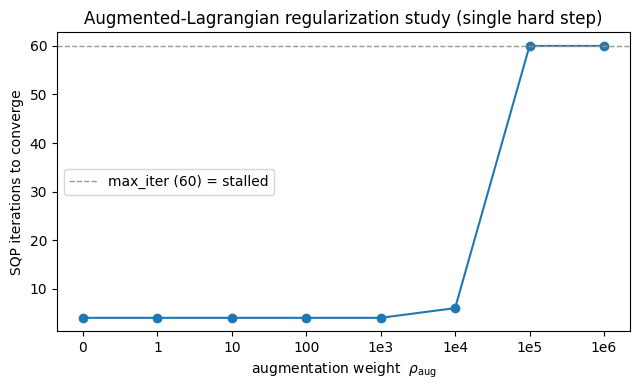

In [ ]:
h_study = 1.0                     # large timestep => one genuinely hard step
rho_sweep = [0.0, 1.0, 10.0, 100.0, 1e3, 1e4, 1e5, 1e6]
MAXIT = 60

_u0, _a0, _ll0 = mfem_rest_state()
_zc, _zp = _u0.copy(), _u0.copy()

_h_save = h
h = h_study                          # block closures read the global timestep
iters = []
for ra in rho_sweep:
    _cnt = {"n": 0}
    def _hb(pp, _ra=ra):
        _cnt["n"] += 1
        return mfem_hess_blocks(pp, _zc, _zp, _ra)
    p = np.vstack([_u0, _a0, _ll0])
    sqp_mfem(p, lambda pp, _ra=ra: mfem_energy(pp, _zc, _zp, _ra),
             _hb, lambda pp, _ra=ra: mfem_grad_blocks(pp, _zc, _zp, _ra),
             tolerance=1e-6, max_iter=MAXIT, do_line_search=True)
    iters.append(_cnt["n"])
h = _h_save

for ra, it in zip(rho_sweep, iters):
    tag = "   (hit max_iter -- stalled)" if it >= MAXIT else ""
    print(f"rho_aug = {ra:9.0f}:  {it:2d} SQP iterations{tag}")

labels = ["0", "1", "10", "100", "1e3", "1e4", "1e5", "1e6"]
plt.figure(figsize=(6.5, 4))
plt.plot(range(len(rho_sweep)), iters, "o-", color="tab:blue")
plt.axhline(MAXIT, ls="--", c="0.6", lw=1, label=f"max_iter ({MAXIT}) = stalled")
plt.xticks(range(len(rho_sweep)), labels)
plt.xlabel(r"augmentation weight  $\rho_{\mathrm{aug}}$")
plt.ylabel("SQP iterations to converge")
plt.title("Augmented-Lagrangian regularization study (single hard step)")
plt.legend(); plt.tight_layout(); plt.show()

## Compare a few frames

The two methods agree closely: the pinned beam swings down and oscillates under
gravity. MFEM reproduces the FEM motion while solving only in the small subspace
with an element-local elastic energy.


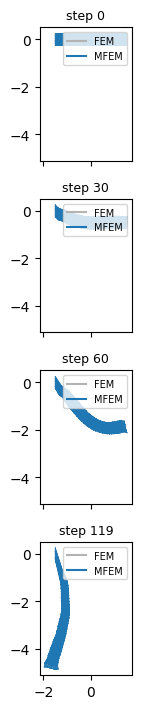

In [9]:
sel = [0, num_steps//4, num_steps//2, num_steps-1]
fig, axes = plt.subplots(len(sel), 1, figsize=(7, 1.8*len(sel)), sharex=True, sharey=True)
for ax, fi in zip(axes, sel):
    ax.triplot(fem_frames[fi][:,0],  fem_frames[fi][:,1],  T, color="0.7", lw=0.6)
    ax.triplot(mfem_frames[fi][:,0], mfem_frames[fi][:,1], T, color="C0", lw=0.6)
    ax.plot([], [], color="0.7", label="FEM"); ax.plot([], [], color="C0", label="MFEM")
    ax.set_title(f"step {fi}", fontsize=9); ax.set_aspect("equal"); ax.legend(loc="upper right", fontsize=7)
fig.tight_layout(); plt.show()

## Animation

A side-by-side animation of the dropping beam (FEM in gray, MFEM in blue).


In [10]:
allpts = np.concatenate(mfem_frames + fem_frames, axis=0)
xmin, ymin = allpts.min(0) - 0.1; xmax, ymax = allpts.max(0) + 0.1

fig, ax = plt.subplots(figsize=(7, 3))
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax); ax.set_aspect("equal")
fem_lines  = ax.triplot(fem_frames[0][:,0],  fem_frames[0][:,1],  T, color="0.7", lw=0.6)
mfem_lines = ax.triplot(mfem_frames[0][:,0], mfem_frames[0][:,1], T, color="C0", lw=0.6)
ax.plot([], [], color="0.7", label="FEM"); ax.plot([], [], color="C0", label="MFEM")
ax.legend(loc="upper right")

def draw(fi):
    ax.clear()
    ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax); ax.set_aspect("equal")
    ax.triplot(fem_frames[fi][:,0],  fem_frames[fi][:,1],  T, color="0.7", lw=0.6)
    ax.triplot(mfem_frames[fi][:,0], mfem_frames[fi][:,1], T, color="C0", lw=0.6)
    ax.set_title(f"drop under gravity - step {fi}", fontsize=10)
    return []

anim = animation.FuncAnimation(fig, draw, frames=range(0, num_steps, 2), interval=60, blit=False)
plt.close(fig)
HTML(anim.to_jshtml())

## So why did we do all this? &mdash; iterations to converge

We compare the solver iterations for a single backward-Euler step as the material
stiffens: **full Newton** on the FEM energy vs the **SQP** on the MFEM blocks.

A caveat, stated up front: **iteration count is not where the mixed method wins.**
Full Newton converges quadratically and is hard to beat on raw count &mdash; here
MFEM is comparable (slightly fewer), and if you push the per-step deformation hard
the local-global SQP actually needs *more*. The real payoff is the **cost of each
iteration**: MFEM evaluates the elastic energy / gradient / Hessian at only the
`k` cubature points (not all `T` triangles) and condenses the element-local stretch,
so each iteration is far cheaper and &mdash; crucially &mdash; **independent of mesh
resolution**. The subspace shrinks the linear solve to `m` DOFs; the cubature shrinks
the elastic assembly from `T` elements to `k`.

ym = 1e+04:   FEM Newton = 4 iters,   MFEM SQP = 2 iters
ym = 1e+05:   FEM Newton = 3 iters,   MFEM SQP = 2 iters
ym = 1e+06:   FEM Newton = 3 iters,   MFEM SQP = 2 iters
ym = 1e+07:   FEM Newton = 3 iters,   MFEM SQP = 2 iters
ym = 1e+08:   FEM Newton = 3 iters,   MFEM SQP = 3 iters
ym = 1e+09:   FEM Newton = 3 iters,   MFEM SQP = 3 iters

Per iteration the FEM solve touches all 546 triangles and a 60-dof system;
MFEM touches only 40 cubature points (14x fewer) and condenses the stretch element-locally.


/tmp/claude-502/ipykernel_17863/3347769848.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lag  = float(ll.T @ wc)                           # ll^T W c
/tmp/claude-502/ipykernel_17863/3347769848.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  aug  = 0.5 * ra * float(c.T @ wc)                 # 0.5 rho c^T W c


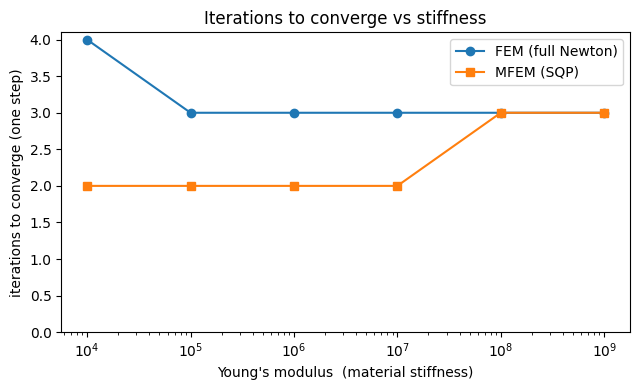

In [11]:
# One backward-Euler step from rest; sweep stiffness, count solver iterations.
ym_sweep = [1e4, 1e5, 1e6, 1e7, 1e8, 1e9]
u0, a0, ll0 = mfem_rest_state()
z_curr = z_prev = u0

_mu_save, _lam_save = mu, lam
fem_its, mfem_its = [], []
for ym_i in ym_sweep:
    mu_i, lam_i = sk.ympr_to_lame(ym_i, pr)
    mu  = np.full((T.shape[0], 1), mu_i)[cI]
    lam = np.full((T.shape[0], 1), lam_i)[cI]

    # FEM: full-Newton iterations to converge
    v  = (z_curr - z_prev) / h
    z0 = z_curr + v * h
    _, info = newton_solver(z0,
                lambda zz: fem_energy(zz, z_curr, z_prev),
                lambda zz: fem_grad(zz, z_curr, z_prev),
                lambda zz: fem_hess(zz, z_curr, z_prev),
                tolerance=1e-6, max_iter=40, do_line_search=True, return_info=True)
    fem_its.append(info["iters"] + 1)

    # MFEM: SQP iterations to converge (count hess_blocks calls = iterations)
    _cnt = {"n": 0}
    def _hb(pp):
        _cnt["n"] += 1
        return mfem_hess_blocks(pp, z_curr, z_prev, rho_aug)
    p = np.vstack([z_curr, a0, ll0])
    sqp_mfem(p, lambda pp: mfem_energy(pp, z_curr, z_prev, rho_aug),
             _hb, lambda pp: mfem_grad_blocks(pp, z_curr, z_prev, rho_aug),
             tolerance=1e-6, max_iter=40, do_line_search=True)
    mfem_its.append(_cnt["n"])
mu, lam = _mu_save, _lam_save

for ym_i, fi, mi in zip(ym_sweep, fem_its, mfem_its):
    print(f"ym = {ym_i:.0e}:   FEM Newton = {fi} iters,   MFEM SQP = {mi} iters")
print(f"\nPer iteration the FEM solve touches all {T.shape[0]} triangles and a "
      f"{B.shape[1]}-dof system;\nMFEM touches only {cI.shape[0]} cubature points "
      f"({T.shape[0]/cI.shape[0]:.0f}x fewer) and condenses the stretch element-locally.")

plt.figure(figsize=(6.5, 4))
plt.semilogx(ym_sweep, fem_its,  "o-", label="FEM (full Newton)")
plt.semilogx(ym_sweep, mfem_its, "s-", label="MFEM (SQP)")
plt.xlabel("Young's modulus  (material stiffness)")
plt.ylabel("iterations to converge (one step)")
plt.title("Iterations to converge vs stiffness")
plt.ylim(bottom=0); plt.legend(); plt.tight_layout(); plt.show()

## Takeaways

* **Mixed FEM** trades the dense subspace elastic Hessian for an element-local
  one ($H_z$ block-diagonal) plus a cheap constraint, so each iteration is a
  single small dense subspace solve.
* The **flat `sqp_mfem`** solver eliminates the Lagrange multiplier: you give it
  $[\mathbf{u};\mathbf{a}]$ and the five Hessian blocks
  `[H_u, H_z, G_u, G_z, G_zi]`, and it condenses the diagonal $G_z$ into the
  position update internally.
* Composed entirely from flat simkit functions &mdash; the same pieces FEM uses,
  plus the stretch map and constraint &mdash; with no simulator class in sight.

See `examples/interactive_demos/012_interactive_mixed_fem.py` for a live,
mouse-draggable version of this solver.

* The augmented-Lagrangian gradient w.r.t. positions is $\rho_{\text{aug}}\,\frac{\partial S}{\partial u}^\top W\mathbf c$ &mdash; weighting the residual by $W$ **once**, matching the $\tfrac12\rho_{\text{aug}}\mathbf c^\top W\mathbf c$ penalty and its Gauss-Newton Hessian (`tests/test_mfem_blocks.py` pins this down).
* `rho_aug` trades line-search robustness against conditioning: a modest value rescues stalls on hard steps, but too large a value slows the solve.